# Notebook Instructions

1. If you are new to Jupyter notebooks, please go through this introductory manual <a href='https://quantra.quantinsti.com/quantra-notebook' target="_blank">here</a>.
1. Any changes made in this notebook would be lost after you close the browser window. **You can download the notebook to save your work on your PC.**
1. Before running this notebook on your local PC:<br>
i.  You need to set up a Python environment and the relevant packages on your local PC. To do so, go through the section on "**Run Codes Locally on Your Machine**" in the course.<br>
ii. You need to **download the zip file available in the last unit** of this course. The zip file contains the data files and/or python modules that might be required to run this notebook.

# Backtest the Inverse Head and Shoulders Pattern


In the previous notebook, you learnt how to identify the inverse head and shoulders pattern and generated the risk metrics. In this notebook, you will learn to backtest the inverse head and shoudlers pattern and generate a trade sheet.

This notebook is structured as follows:
1. [Import Libraries](#libraries)
2. [Read the Data](#data)
3. [Merge the Data With Pattern Details](#merge)
4. [Backtest and Trade Sheet](#backtest)
5. [Trade Level Analytics](#trade-level-analytics)
6. [Conclusion and Next Steps](#conclusion)

<a id='libraries'></a>
## Import Libraries

In [1]:
# For data manipulation
import pandas as pd
import numpy as np

# Import utility functions 
import sys
sys.path.append('..')
from data_modules.price_action_util_quantra import backtester,trade_level_analytics,get_performance_metrics

<a id='data'></a>
## Read the Data
Import the file `apple_daily_1980_2022.csv` using the `read_csv` method of `pandas`. This file has the OHLCV values for Apple stock in the daily frequency. Similarly, import the file `ihs_pattern_details.csv` which has all the details of the inverse head and shoulders patterns identified in Apple's daily data from 1980 to 2022. These CSV files are available in the zip file of the unit 'Python Codes and Data' in the 'Course Summary' section.

In [2]:
# Import the stock price data
data = pd.read_csv(
    '../data_modules/apple_daily_1980_2022.csv', index_col=0)

# Change the index type to datetime
data.index = pd.to_datetime(data.index)

# Import the pattern details of the inverse head and shoulders
pattern_details = pd.read_csv(
    '../data_modules/ihs_pattern_details.csv', index_col=0)

# Convert the confirmation_date column type to datetime
pattern_details.confirmation_date = pd.to_datetime(
    pattern_details.confirmation_date)

# Convert the index of pattern_details to 'confirmation_date' column
pattern_details.index = pattern_details.confirmation_date

pattern_details.tail()

,sh1_date,neck1_date,head_date,neck2_date,sh2_date,sh1_price,neck1_price,head_price,neck2_price,sh2_price,confirmation_date,time_for_confirmation,signal,stoploss,head_length,target
confirmation_date,,,,,,,,,,,,,,,,
2015-01-28,2014-12-16,2014-12-29,2015-01-06,2015-01-09,2015-01-16,23.952008,25.870246,23.584591,25.527619,23.713076,2015-01-28,12,1,23.475945,1.943028,27.470647
2018-01-17,2017-11-15,2017-11-24,2017-12-06,2017-12-18,2017-12-29,40.094529,41.789937,39.637336,42.194735,40.294549,2018-01-17,19,1,39.891603,2.557399,44.752135
2018-03-12,2017-12-29,2018-01-18,2018-02-09,2018-02-28,2018-03-02,40.294549,42.885284,35.920906,43.184456,41.231089,2018-03-12,10,1,40.818778,7.263551,50.448007
2018-06-01,2018-04-02,2018-04-17,2018-04-27,2018-05-11,2018-05-23,39.323164,42.782787,38.405042,45.616704,44.584639,2018-06-01,9,1,44.138792,7.211662,52.828365
2021-04-07,2021-02-23,2021-03-02,2021-03-08,2021-03-16,2021-03-30,117.354828,127.594507,115.193885,126.107612,117.820724,2021-04-07,8,1,116.642516,10.913727,137.021340


 <a id='merge'></a>
 ## Merge the Data With Pattern Details
 Generate a signal column in `data` and merge the `data` with the pattern details

In [3]:
# Merge the 'pattern_details' dataframe with 'data' dataframe
data = pd.merge(data, pattern_details, left_index=True,
                right_index=True, how='left')

# Replacing NaN values in 'signal' column with '0'
data['signal'] = data.signal.fillna(0)
data.tail()

,Open,High,Low,Close,Volume,sh1_date,neck1_date,head_date,neck2_date,sh2_date,...,neck1_price,head_price,neck2_price,sh2_price,confirmation_date,time_for_confirmation,signal,stoploss,head_length,target
Date,,,,,,,,,,,,,,,,,,,,,
2022-10-04,145.029999,146.220001,144.259995,146.100006,87830100,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaT,NaN,0.0,NaN,NaN,NaN
2022-10-05,144.070007,147.380005,143.009995,146.399994,79471000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaT,NaN,0.0,NaN,NaN,NaN
2022-10-06,145.809998,147.539993,145.220001,145.429993,68402200,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaT,NaN,0.0,NaN,NaN,NaN
2022-10-07,142.539993,143.100006,139.449997,140.089996,85859100,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaT,NaN,0.0,NaN,NaN,NaN
2022-10-10,140.419998,141.889999,138.570007,140.419998,74827900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaT,NaN,0.0,NaN,NaN,NaN


 <a id='backtest'></a>
## Backtest and Generate Trade Sheet

Using the backtester function, generate the trade sheet for inverse head and shoulders pattern

In [4]:
# Use backtester function to generate trade sheet
tradesheet = backtester(data)

Trade No: 1 | Entry Date: 1981-04-08 00:00:00 | Entry Price: 0.09 | Position: 1.0
Exit Type: TP | Exit Date: 1981-05-27 00:00:00 | Exit Price: 0.11 | PnL: 0.02 | Cum PnL: 0.02
------------------------------
Trade No: 2 | Entry Date: 1987-04-21 00:00:00 | Entry Price: 0.26 | Position: 1.0
Exit Type: TP | Exit Date: 1987-06-22 00:00:00 | Exit Price: 0.29 | PnL: 0.03 | Cum PnL: 0.05
------------------------------
Trade No: 3 | Entry Date: 1988-06-06 00:00:00 | Entry Price: 0.31 | Position: 1.0
Exit Type: SL | Exit Date: 1988-09-01 00:00:00 | Exit Price: 0.27 | PnL: -0.04 | Cum PnL: 0.01
------------------------------
Trade No: 4 | Entry Date: 1991-08-01 00:00:00 | Entry Price: 0.36 | Position: 1.0
Exit Type: TP | Exit Date: 1991-12-30 00:00:00 | Exit Price: 0.41 | PnL: 0.05 | Cum PnL: 0.06
------------------------------
Trade No: 5 | Entry Date: 1993-11-16 00:00:00 | Entry Price: 0.25 | Position: 1.0
Exit Type: SL | Exit Date: 1993-12-10 00:00:00 | Exit Price: 0.21 | PnL: -0.04 | Cum PnL:

 <a id='trade-level-analytics'></a>
## Trade Level Analytics
Using the `trade_level_analytics()` function,  calculate the trade level analytics.

In [5]:
# Trade level analytics
trade_level_analytics(tradesheet)

,Strategy
Total PnL,8.97
total_trades,15
Number of Winners,9
Number of Losers,6
Win (%),60.0
Loss (%),40.0
per_trade_PnL_winners,1.977778
per_trade_PnL_losers,1.471667
Average holding time,64 days 17:36:00
Profit Factor,2.015855


The inverse head and shoulders pattern generated 23 trades over the backtested period out of which 13 were profitable trades. The  profit factor is 2.7. Any strategy with a profit factor of more than 2 is considered to be excellent.
<a id='strategy-performance'></a>
## Strategy Performance
Analyse the strategy's performance by using the `get_performance_metrics()` function. But before that, update the `signal` column in `data` for the date range between the entry and exit dates with the corresponding position. This process helps in marking the periods during which certain trades were active in the `data` DataFrame.

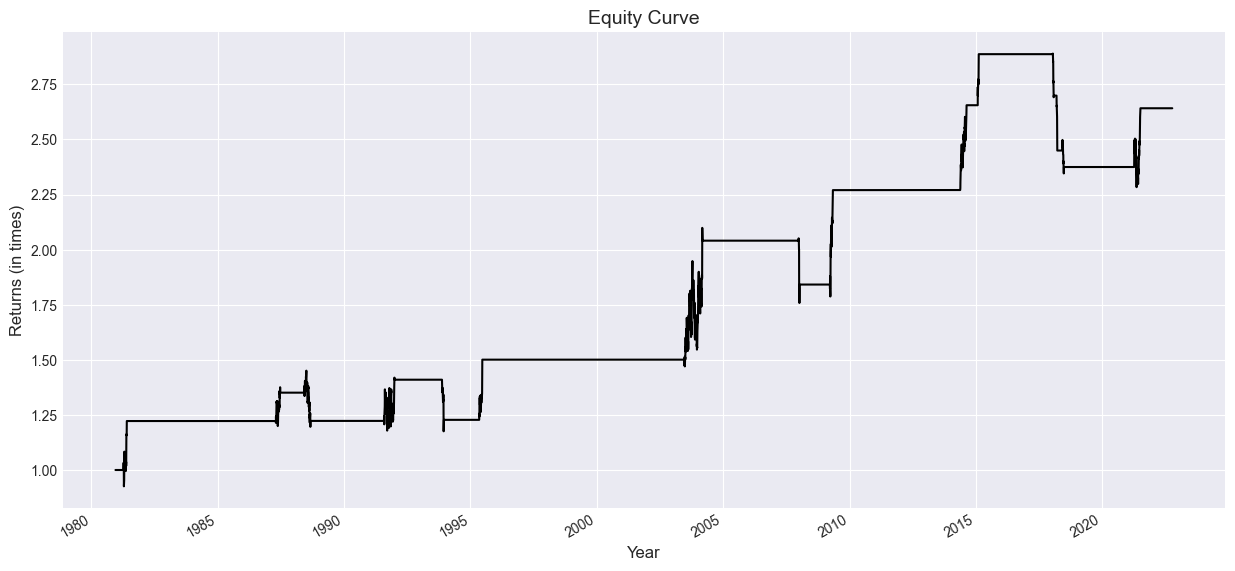

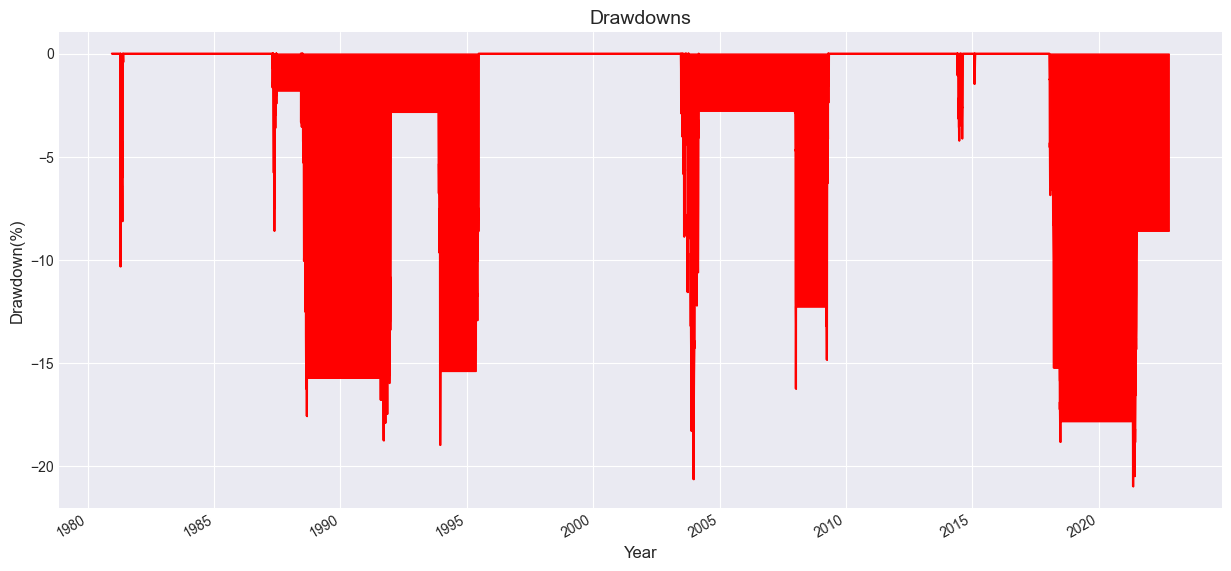

                 Strategy
CAGR                2.35%
Sharpe Ratio         0.08
Maximum Drawdown  -20.98%


In [6]:
# Iterate over each row in the 'trades' DataFrame
for index, trade in tradesheet.iterrows():
    # Extract the entry date of the trade
    entry_date = trade['entry_date']
    
    # Extract the exit date of the trade
    exit_date = trade['exit_date']
    
    # Extract the position of the trade (e.g., -1 for short)
    position = trade['position']
    
    # Update the 'signal' column in the 'data' DataFrame for the date range
    # between the entry date and the exit date with the corresponding position
    data.loc[entry_date:exit_date, 'signal'] = position
    
# Strategy performance
get_performance_metrics(data)

Over the backtested period, the strategy generated a CAGR of 2.35% with a sharpe ratio of 0.08 and a maximum drawdown of 20.98%.
<a id='conclusion'></a>
## Conclusion and Next Steps
In this notebook, you have learnt to backtest the inverse head and shoulders pattern and analysed its performance across the historical time period. You can also download and test the performance of the pattern on any other asset of your choice.